## Tarefa Prática para o Método dos Mínimos Quadrados

In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
xi = np.array([-3, -1, 1, 2, 3]);
yi = np.array([-1, 0, 1, 1, -1]);

n = len(xi)

x = np.linspace(xi[0], xi[-1], 100)

A = np.array([xi, xi ** 2, np.ones(n)]).T

print(A)

[[-3.  9.  1.]
 [-1.  1.  1.]
 [ 1.  1.  1.]
 [ 2.  4.  1.]
 [ 3.  9.  1.]]


In [46]:
def f(x):
    return 1 / (x ** 4)

def phi1(x):
    return x ** 2

def phi2(x):
    return x ** 4

def P(x, a, b):
    return a * x**2 + b * x**4

## calcula a integral baseado na integral de riemann
def integral(f, inicio, fim, n=10000000):
    dx = (fim - inicio) / n

    soma = 0

    for i in range(n):

        x = inicio + i * dx

        soma += f(x)

    return soma * dx


def produto_interno(f, g):
    
    def integrando(x):
        return (x ** 2) * f(x) * g(x)

    # comeca com 10e-3 paraa evitar divisao por zero
    return integral(integrando, 10e-3, 1)

#Calclando a Matriz de Gram
A11 = produto_interno(phi1, phi1)
A12 = produto_interno(phi1, phi2)
A21 = produto_interno(phi2, phi1)
A22 = produto_interno(phi2, phi2)

B1 = produto_interno(f, phi1)
B2 = produto_interno(f, phi2)

A11 = produto_interno(phi1, phi1)
A12 = produto_interno(phi2, phi1)

A21 = produto_interno(phi1, phi2)
A22 = produto_interno(phi2, phi2)

B1 = produto_interno(f, phi1)
B2 = produto_interno(f, phi2)

A = np.array([
    [A11, A12],
    [A21, A22]
])

B = np.array([
    B1,
    B2
])

coeficientes = np.linalg.solve(A, B)

print("Matriz A:\n", A)
print("Vetor B:\n", B)
print(f"\nCoeficientes: a = {coeficientes[0]}, b = {coeficientes[1]}")


Matriz A:
 [[0.14285709 0.11111106]
 [0.11111106 0.09090904]]
Vetor B:
 [0.99       0.33333295]

Coeficientes: a = 82.58258922254939, b = -97.26762125688916


In [47]:
F1 = f(0.4)
print(f"f(0.4) = {F1}")
P1 = P(0.4, coeficientes[0], coeficientes[1])
print(f"P(0.4) = {P1}")

F2 = f(0.9)
print(f"f(0.9) = {F2}")
P1 = P(0.9, coeficientes[0], coeficientes[1])
print(f"P(0.9) = {P1}")

f(0.4) = 39.06249999999999
P(0.4) = 10.723163171431542
f(0.9) = 1.5241579027587258
P(0.9) = 3.0746109636200245


Nos testes feitos com $x_1 = 0.4$ e $x_2 = 0.9$, podemos oservar que próximo de 0, o valor de f(x) é significantemente maior, já que a função $f(x) = \frac{1}{x^4}$ "explode", com valores próximos de zero. Já com valores mais próximos de 1 a aproximação é melhor.

P1(x) = -0.19776119402985076x² + 0.11567164179104476x + 0.9029850746268657
P2(x) = 0.7068965517241383x + -0.07758620689655177x³


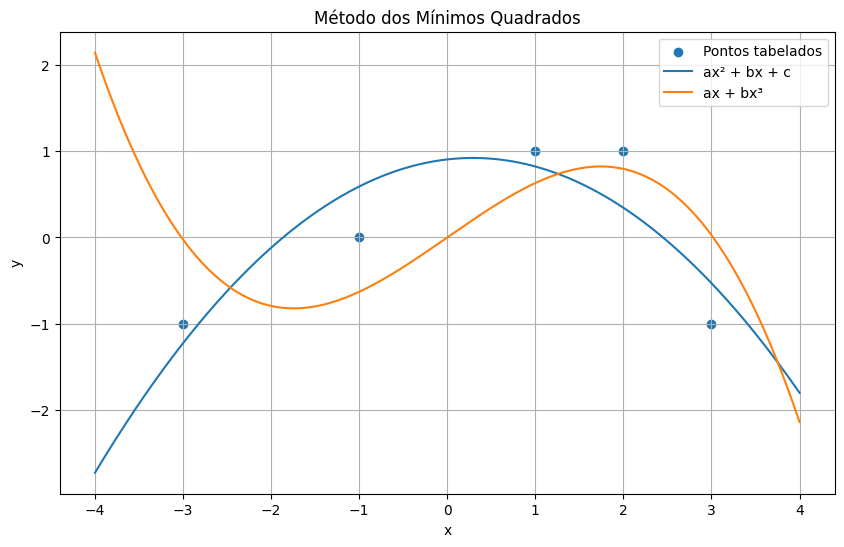

In [48]:
A1 = np.array([
    [xi[0] ** 2, xi[0], 1],
    [xi[1] ** 2, xi[1], 1],
    [xi[2] ** 2, xi[2], 1],
    [xi[3] ** 2, xi[3], 1],
    [xi[4] ** 2, xi[4], 1]
])

M1 = A1.T @ A1
B1 = A1.T @ yi

coef1 = np.linalg.solve(M1, B1)

a = coef1[0]
b = coef1[1]
c = coef1[2]


#equacao da parabola
print(f"P1(x) = {a}x² + {b}x + {c}")

def P1(x):
    return a * (x ** 2) + b * x + c

A2 = np.array([
    [xi[0], xi[0] ** 3],
    [xi[1], xi[1] ** 3],
    [xi[2], xi[2] ** 3],
    [xi[3], xi[3] ** 3],
    [xi[4], xi[4] ** 3]
])

M2 = A2.T @ A2
B2 = A2.T @ yi

coef2 = np.linalg.solve(M2, B2)

a2 = coef2[0]
b2 = coef2[1]

#equacao
print(f"P2(x) = {a2}x + {b2}x³")
def P2(x):
    return a2 * x + b2 * (x ** 3)

x = np.linspace(-4, 4, 500)

y1 = P1(x)
y2 = P2(x)

plt.figure(figsize=(10,6))

plt.scatter(xi, yi, label='Pontos tabelados')
plt.plot(x, y1, label='ax² + bx + c')
plt.plot(x, y2, label='ax + bx³')
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Método dos Mínimos Quadrados")
plt.legend()
plt.show()

